# Aplicación de modelos de machine learning

## Objeto de estudio

El dataset seleccionado es un conjunto de datos que contiene la variable objetivo diagnóstico (diagnosis), el cual, a través de una serie de variables, nos indica qué tipo de tumor tiene un paciente, sea benigno (B) o maligno (M).

El objeto del presente estudio, es realizar un análisis mediante aprendizaje no supervisado, esto para identificar grupos con características similares que nos permita asociar variables y concluir sobre un diagnóstico.

## Actores y contextos

Con base en los datos que se recolectan en un entorno médico, es decir, información recopilada de un gran número de pacientes, es posible aplicar modelos predictivos de machine learning, con el objetivo de identificar patrones que permitan descubrir y tratar afecciones de salud a temprana edad.

Para lograr lo anterior, procederemos a eliminar la variable objetivo *diagnosis* para evitar sesgos en el modelo. Posteriormente, aplicar el modelo Kmeans basado en el número de clusters para llegar al objetivo.

## Objetivos

- Fortalecer la destreza en el uso del aprendizaje no supervisado.
- Aplicar el modelo Kmeans y un determinado número de cluster para obtener un grupo de datos con características similares.
- Con base en las agrupaciones resultantes, caracterizar a la población que presenta tumores benignos y malignos.

## Desarrollo

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
Datos = pd.read_csv('breast-cancer.csv')
Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

- Usando el método .info(), y con un primer análisis de los datos tenemos que, consta de 569 entradas, 32 columnas y cada una de ellas tiene los datos completos, por tanto no hay datos nulos. Además, el tipo de datos corresponde a valores en decimales (float), entero (int) y texto (object).

- Podemos afirmar que no es necesario efectuar algún tipo de rellenado de valores.

In [ ]:
Datos.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [ ]:
Datos.describe(include='all')

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.037183e+07,NaN,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,NaN,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,NaN,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,NaN,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,NaN,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,NaN,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080


- De acuerdo con el método .describe(), la variable objetivo tiene dos tipos de respuesta, tumos benigno (B) y tumor maligno (M).
- El resultado más común en la población es B, con una freuencia de 357 veces, esto nos permite afirmar que la población tiene tumores benignos en su mayoría.

### Eliminación de datos irrelevantes

- Teniendo en cuenta que el objetivo del estudio es caracterizar la población en grupos con diagnóstico de tumor benigno y maligno, observamos que el dataset cuenta con variables irrelevantes para el análisis, y que, a su vez, pueden generar algún tipo de ruido para el modelo. Por tanto, se decide eliminar la columna "id" y la variable objetivo "diagnois", la primera para reducir el ruido en los datos, y la segunda, para evitar sesgos.

In [ ]:
Datos.drop(columns=['id', 'diagnosis'], inplace=True)

In [ ]:
Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

Ahora, contamos con 30 columnas de datos completos y de tipo decimal (float).

In [ ]:
Datos.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
from sklearn.cluster import KMeans
inertia = []
range_n_clusters = range(1, 10)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state = 42)
    kmeans.fit(Datos)
    inertia.append(kmeans.inertia_)

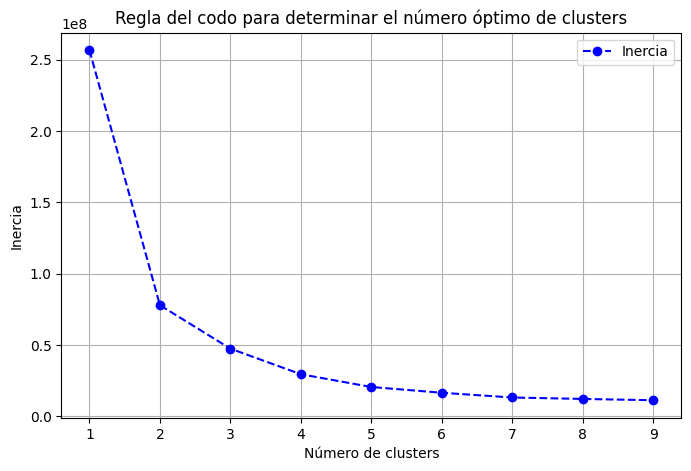

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--', color='b', label='Inercia')
plt.title("Regla del codo para determinar el número óptimo de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.xticks(range_n_clusters)
plt.grid()
plt.legend()
plt.show()

- Con base en la gráfica de la regla del codo, seleccionamos un K = 2

In [ ]:
k = 2
kmeans = KMeans(n_clusters = k)
kmeans.fit(Datos)

KMeans(n_clusters=2)

In [ ]:
clusters = kmeans.fit_predict(Datos)

In [ ]:
Datos['group'] = clusters

In [ ]:
Datos.head(10)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,group
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,1
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


- Como podemos ver en la tabla anterior, se ha agregado una columna al final, a cual es "group" y contiene únicamente dos valores (0 y 1), de tal manera que, si lo comparamos con el dataset inicial, el valor 1 corresponde a un diagnóstico "maligno", y por tanto, el valor 0 es "benigno".

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(Datos)

Datos['PCA1'] = X_pca[:, 0]
Datos['PCA2'] = X_pca[:, 1]

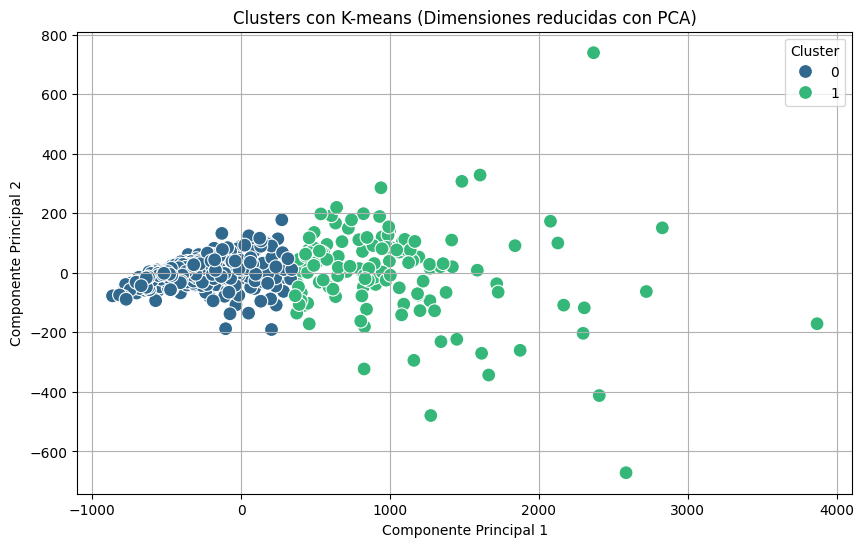

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=Datos, x='PCA1', y='PCA2', hue='group', palette='viridis', s=100)
plt.title("Clusters con K-means (Dimensiones reducidas con PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.grid()
plt.show()

- Observando la gráfica donde se relaciona el modelo Kmeans, podemos identificar que el grupo 0 (color azul) tiene sus datos muy concentrados, mientras que el grupo 1 (verde) presenta datos más dispersos.
- Tambien podemos afirmar que, las características del grupo 0, tienen mayor relación entre sus datos, en comparación a una menor relación del grupo 1.

In [ ]:
fig = px.histogram(
    data_frame=Datos,
    x='group',
    color='group',
    color_discrete_sequence=['#A865C9', '#f6abb6']
)

fig.update_layout(
    title='Distribución por Grupo',
    xaxis_title='Grupo/Diagnóstico',
    yaxis_title='Frecuencia',
)

fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=['Grupo 0', 'Grupo 1']
)

fig.show()

- De acuerdo con el gráfico anterior, podemos observar que el "grupo 0" es el conjunto donde se concentra la mayor cantidad de datos, y éste corresponde a 438 pacientes cuyo diagnóstico es la presencia de un tumor benigno. Por otra parte, en el "grupo 1", están 131 pacientes cuyo diagnóstico comprende la presencia de tumor maligno.

### Matriz de correlación

- Para elaborar la matriz de correlación de forma objetiva, eliminaremos las variables irrelevantes, como por ejemplo, el target, que en nuestro caso es la variable group, así mismo, las variables PCA1 Y PCA2.

In [ ]:
Datos.drop(columns=['group', 'PCA1', 'PCA2'], inplace=True)

In [ ]:
Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

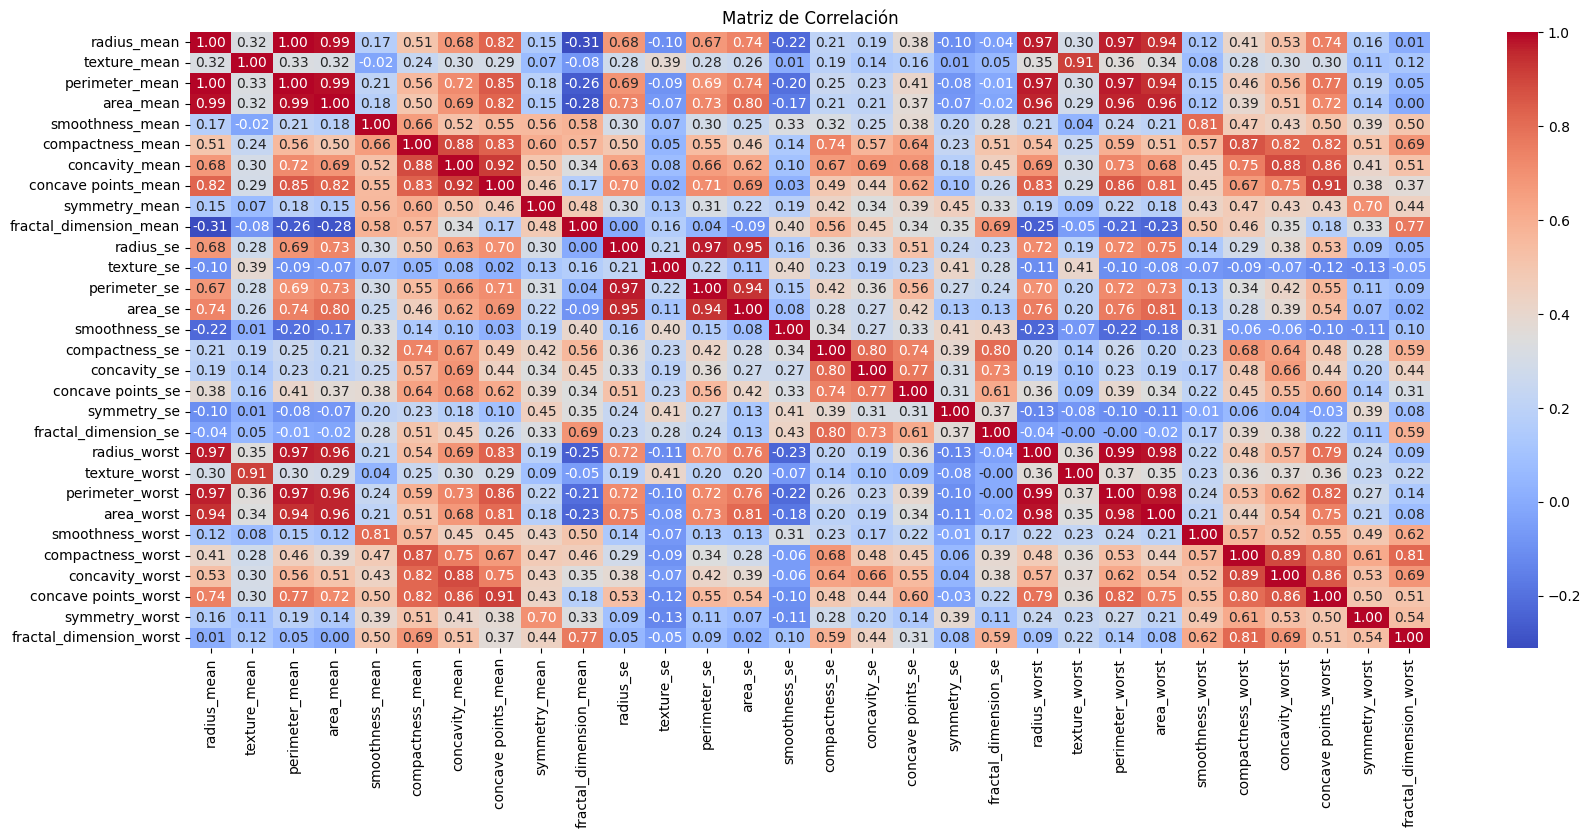

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(Datos.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación")
plt.show()

Con base en la matriz de correlación, podemos concluir lo siguiente:
- El dataset contiene varias características altamente relacionadas.
- Variables como radio, perímetro y áreas tienen correlaciones muy cercanas y del 100%, esto es comprensible, dado que son valores provenientes de fórmulas matemáticas que son directamente proporcionales.
- Existen otras variables con muy buena correlación, es decir, características como; punto cóncavos y perímetros tienen una correlación superior al 80%.

## Conclusiones

- Aplicamos el aprendizaje supervisado y agrupamos el dataset en dos conjuntos, el grupo 0 para pacientes con tumor benigno y el grupo 1 para tumores malignos.
- Previamente, definimos un cluster muy adecuado para nuestro análisis objetivo, lo cual permitió la correcta aplicación del modelo Kmeans.
- El resultado presenta un conjunto de datos altamente desequilibrado. Ante la presente situación, el modelo será más eficiente detectando casos con tumores benignos, y en contra parte, poco eficiente para detectar tumores malignos, esto debido a que no logró encontrar la suficiente relación con tan pocos datos, a este tipo de resultados también se les conoce como error de bajo entrenamiento.
- El error de bajo entrenamiento lo que nos ofrece es un modelo muy bueno para identificar cierta característica, pero muy malo para identificar otra.

## Referencias bibliográficas

- Bonaccorso, G. (2018). Machine Learning Algorithms: Popular Algorithms for
Data Science and Machine Learning (pp. 104-140).
- Campesato, O. (2020). Artificial Intelligence, Machine Learning, and Deep
Learning (pp. 23-57).
